# Lesson 14 — All Surrogates Comparison

**Goal**: Compare GP, MC Dropout, Deep Ensembles, RBF, and Random Forest as surrogates inside the same SCR ≤ 20% enforcer BO loop on Forrester (1D) and Branin (2D).

**SCR definition** (from Lesson 13):
```
SCR = surrogate_only_calls / (true_calls + surrogate_only_calls)  ≤ 20%
```
The enforcer checks projected SCR before each step — if using the surrogate would push SCR above the ceiling, the true function is called instead.

**Key question**: Which surrogate gives the best convergence per true evaluation, and at what computational cost?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, spearmanr
from scipy.optimize import minimize
from scipy.interpolate import RBFInterpolator
from sklearn.ensemble import RandomForestRegressor
import torch
import torch.nn as nn
import time

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

N_INIT     = 10
N_INIT_2D  = 15
N_ITER     = 25
N_SEEDS    = 3
SCR_MAX    = 0.20
EPOCHS_VIZ = 2000
EPOCHS_BO  = 500
N_MEMBERS  = 5
T_DROPOUT  = 50

SURROGATES = ['gp', 'mc_dropout', 'deep_ensemble', 'rbf', 'rf']
LABELS     = ['GP', 'MC Dropout', 'Deep Ensemble', 'RBF', 'Random Forest']
COLORS     = ['steelblue', 'seagreen', 'darkorange', 'tomato', 'purple']

print('Libraries loaded.')

Libraries loaded.


## Benchmarks and helpers

In [2]:
def forrester(x):
    x = np.asarray(x).ravel()
    return float((6*x[0] - 2)**2 * np.sin(12*x[0] - 4))

def branin(x):
    x = np.asarray(x).ravel()
    x1 = x[0] * 15 - 5
    x2 = x[1] * 15
    return float((x2 - 5.1/(4*np.pi**2)*x1**2 + 5/np.pi*x1 - 6)**2
                 + 10*(1 - 1/(8*np.pi))*np.cos(x1) + 10)

FORRESTER_FSTAR = (6*0.7572 - 2)**2 * np.sin(12*0.7572 - 4)
BRANIN_FSTAR    = 0.397887
print(f'Forrester f* ≈ {FORRESTER_FSTAR:.4f}')
print(f'Branin    f* ≈ {BRANIN_FSTAR:.4f}')

def lhs(n, d, rg):
    pts = np.zeros((n, d))
    for j in range(d):
        pts[:, j] = (rg.permutation(n) + rg.uniform(size=n)) / n
    return pts.astype(np.float32)

def acq_ei(mu, std, f_best, xi=0.01):
    Z = (f_best - xi - mu) / (std + 1e-9)
    return np.maximum((f_best - xi - mu)*norm.cdf(Z) + std*norm.pdf(Z), 0.0)

Forrester f* ≈ -6.0207
Branin    f* ≈ 0.3979


## All 5 surrogate implementations

Each surrogate gets a self-contained `predict(X_tr_std, y_tr_std, X_cand_std) → μ, σ` function.
All inputs/outputs are in **standardised space** (zero mean, unit variance).

In [3]:
# ── GP ──────────────────────────────────────────────────────────────────
def matern52(X1, X2, l=1.0, sf=1.0):
    diff = X1[:, None, :] - X2[None, :, :]
    r    = np.sqrt((diff**2).sum(-1) + 1e-12)
    k    = np.sqrt(5) * r / l
    return sf**2 * (1 + k + k**2/3) * np.exp(-k)

def fit_gp(X_tr, y_tr):
    def nll(lp):
        l, sf, sn = np.exp(lp)
        K = matern52(X_tr, X_tr, l, sf) + (sn**2 + 1e-6)*np.eye(len(X_tr))
        try:
            L = np.linalg.cholesky(K)
        except np.linalg.LinAlgError:
            return 1e10
        a = np.linalg.solve(L.T, np.linalg.solve(L, y_tr))
        return float(0.5*(y_tr @ a) + np.log(np.diag(L)).sum())
    res = minimize(nll, [0., 0., -3.], method='L-BFGS-B', bounds=[(-3,3),(-2,2),(-5,0)])
    return tuple(np.exp(res.x))

def gp_predict(X_tr, y_tr, X_te, l=1.0, sf=1.0, sn=0.01):
    K = matern52(X_tr, X_tr, l, sf) + (sn**2 + 1e-6)*np.eye(len(X_tr))
    L = np.linalg.cholesky(K)
    Ks  = matern52(X_tr, X_te, l, sf)
    Kss = np.diag(matern52(X_te, X_te, l, sf))
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_tr))
    mu    = Ks.T @ alpha
    v     = np.linalg.solve(L, Ks)
    std   = np.sqrt(np.maximum(Kss - (v**2).sum(0), 0.0))
    return mu, std

# ── Neural Networks ─────────────────────────────────────────────────────
class Net(nn.Module):
    def __init__(self, d_in, p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 64), nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, 64),   nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_net(X_tr, y_tr, epochs, seed, lr=1e-3):
    torch.manual_seed(seed)
    model = Net(X_tr.shape[1])
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    Xt    = torch.tensor(X_tr, dtype=torch.float32)
    yt    = torch.tensor(y_tr, dtype=torch.float32)
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        ((model(Xt) - yt)**2).mean().backward()
        opt.step()
    return model

def mc_dropout_predict(X_tr, y_tr, X_cand, seed=42, epochs=EPOCHS_BO):
    model = train_net(X_tr, y_tr, epochs, seed)
    model.train()  # dropout ON at inference
    Xc = torch.tensor(X_cand, dtype=torch.float32)
    with torch.no_grad():
        preds = torch.stack([model(Xc) for _ in range(T_DROPOUT)])
    return preds.mean(0).numpy(), preds.std(0).numpy() + 1e-8

def deep_ensemble_predict(X_tr, y_tr, X_cand, seed=42, epochs=EPOCHS_BO):
    Xc    = torch.tensor(X_cand, dtype=torch.float32)
    preds = []
    for i in range(N_MEMBERS):
        model = train_net(X_tr, y_tr, epochs, seed + i * 17)
        model.eval()
        with torch.no_grad():
            preds.append(model(Xc).numpy())
    preds = np.array(preds)
    return preds.mean(0), preds.std(0) + 1e-8

# ── RBF ─────────────────────────────────────────────────────────────────
def rbf_predict(X_tr, y_tr, X_cand):
    rbf   = RBFInterpolator(X_tr, y_tr, kernel='thin_plate_spline', smoothing=1e-4)
    mu    = rbf(X_cand)
    dists = np.sqrt(((X_cand[:, None, :] - X_tr[None, :, :])**2).sum(-1))
    min_d = dists.min(1)
    std   = min_d / (min_d.max() + 1e-8) + 0.05
    return mu, std

# ── Random Forest ────────────────────────────────────────────────────────
def rf_predict(X_tr, y_tr, X_cand, seed=42):
    rf = RandomForestRegressor(n_estimators=100, random_state=seed, n_jobs=1)
    rf.fit(X_tr, y_tr)
    tree_preds = np.array([t.predict(X_cand) for t in rf.estimators_])
    return tree_preds.mean(0), tree_preds.std(0) + 1e-8

# ── Unified interface ────────────────────────────────────────────────────
def surrogate_predict(stype, X_tr, y_tr, X_cand, seed=42, epochs=EPOCHS_BO):
    if stype == 'gp':
        l, sf, sn = fit_gp(X_tr, y_tr)
        return gp_predict(X_tr, y_tr, X_cand, l, sf, sn)
    elif stype == 'mc_dropout':
        return mc_dropout_predict(X_tr, y_tr, X_cand, seed, epochs)
    elif stype == 'deep_ensemble':
        return deep_ensemble_predict(X_tr, y_tr, X_cand, seed, epochs)
    elif stype == 'rbf':
        return rbf_predict(X_tr, y_tr, X_cand)
    elif stype == 'rf':
        return rf_predict(X_tr, y_tr, X_cand, seed)

print('All surrogate functions defined.')

All surrogate functions defined.


## SCR-enforced BO loop

The same loop from Lesson 13, now accepting any surrogate type. Before each step:
```
projected_scr = (surr_calls + 1) / (true_calls + surr_calls + 1)
if projected_scr ≤ scr_max  →  use surrogate prediction
else                         →  call true function
```

In [4]:
def run_bo(stype, func, dim, seed, scr_max=SCR_MAX, n_init=None,
           n_iter=N_ITER, epochs=EPOCHS_BO):
    if n_init is None:
        n_init = N_INIT_2D if dim > 1 else N_INIT
    rg = np.random.default_rng(seed)
    X  = lhs(n_init, dim, rg)
    y  = np.array([func(x) for x in X])

    true_calls = n_init; surr_calls = 0
    best_true  = float(y.min())
    best_history = [best_true]; true_history = [true_calls]

    for _ in range(n_iter):
        Xm = X.mean(0); Xs = X.std(0) + 1e-8
        ym = float(y.mean()); ys = float(y.std()) + 1e-8
        X_std = (X - Xm) / Xs; y_std = (y - ym) / ys

        Xc     = rg.uniform(0, 1, (500, dim)).astype(np.float32)
        Xc_std = (Xc - Xm) / Xs
        mu_s, std_s = surrogate_predict(stype, X_std, y_std, Xc_std, seed, epochs)
        mu  = mu_s * ys + ym; std = std_s * ys

        ei     = acq_ei(mu, std, float(y.min()))
        idx    = int(np.argmax(ei))
        x_next = Xc[idx]; mu_next = float(mu[idx])

        proj_scr = (surr_calls + 1) / (true_calls + surr_calls + 1)
        use_surr = (scr_max > 0) and (proj_scr <= scr_max)

        if use_surr:
            y_next = mu_next; surr_calls += 1
        else:
            y_next = func(x_next); true_calls += 1
            best_true = min(best_true, y_next)

        X = np.vstack([X, x_next]); y = np.append(y, y_next)
        best_history.append(best_true); true_history.append(true_calls)

    return np.array(best_history), np.array(true_history)

print('run_bo() defined.')

run_bo() defined.


---
## Part 1 — Fit quality on Forrester

All 5 surrogates are trained on the same 15 points. We plot μ ± 2σ for each and compare:
- Does the uncertainty cover the true function?
- Where does each surrogate over/under-estimate uncertainty?

Training all surrogates (Deep Ensemble takes ~30s)...
  GP done
  MC Dropout done
  Deep Ensemble done
  RBF done
  Random Forest done


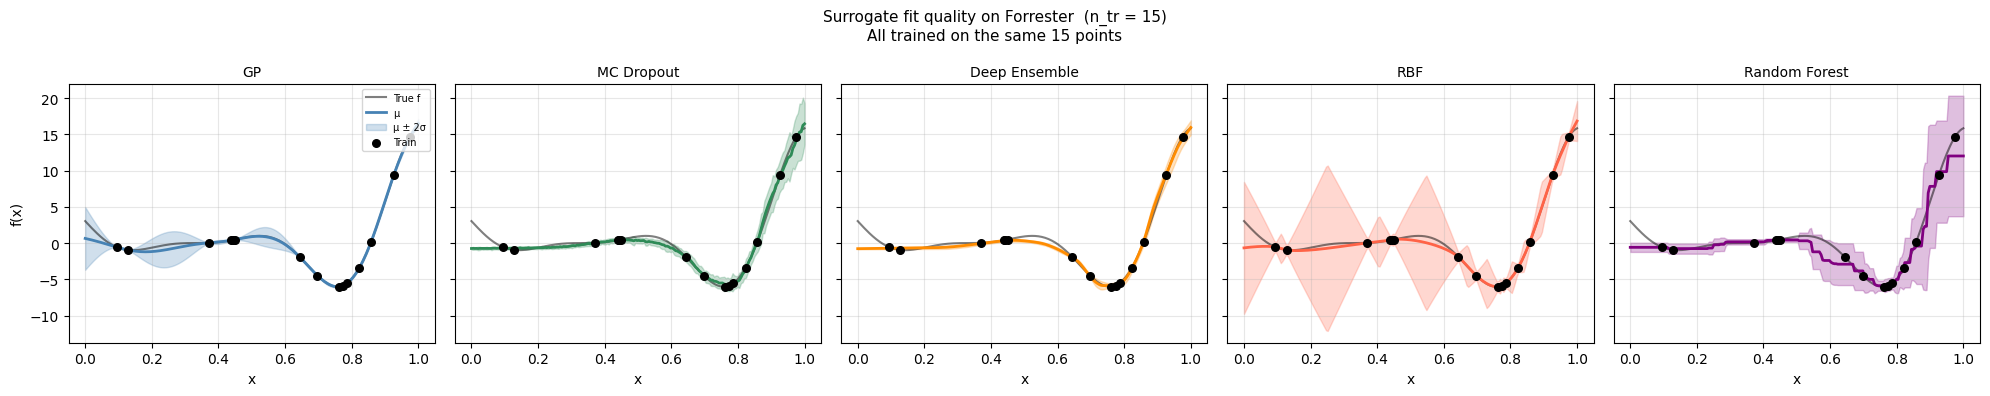

In [5]:
rng_viz = np.random.default_rng(RANDOM_SEED)
n_tr    = 15
X_tr_1d = rng_viz.uniform(0, 1, (n_tr, 1)).astype(np.float32)
y_tr_1d = np.array([forrester(x) for x in X_tr_1d], dtype=np.float32)

Xm1 = float(X_tr_1d.mean()); Xs1 = float(X_tr_1d.std()) + 1e-8
ym1 = float(y_tr_1d.mean()); ys1 = float(y_tr_1d.std()) + 1e-8
X_tr_s = (X_tr_1d - Xm1) / Xs1
y_tr_s = (y_tr_1d - ym1) / ys1

X_grid = np.linspace(0, 1, 200).reshape(-1, 1).astype(np.float32)
y_grid = np.array([forrester(x) for x in X_grid])
Xg_s   = (X_grid - Xm1) / Xs1

print('Training all surrogates (Deep Ensemble takes ~30s)...')
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, stype, label, color in zip(axes, SURROGATES, LABELS, COLORS):
    mu_s, std_s = surrogate_predict(stype, X_tr_s, y_tr_s, Xg_s,
                                    seed=RANDOM_SEED, epochs=EPOCHS_VIZ)
    mu  = mu_s * ys1 + ym1
    std = std_s * ys1
    ax.plot(X_grid, y_grid, 'k-', lw=1.5, alpha=0.5, label='True f')
    ax.plot(X_grid, mu, color=color, lw=2, label='μ')
    ax.fill_between(X_grid.ravel(), mu - 2*std, mu + 2*std,
                    alpha=0.25, color=color, label='μ ± 2σ')
    ax.scatter(X_tr_1d, y_tr_1d, c='black', s=30, zorder=5, label='Train')
    ax.set_title(label, fontsize=10); ax.set_xlabel('x'); ax.grid(True, alpha=0.3)
    print(f'  {label} done')

axes[0].set_ylabel('f(x)')
axes[0].legend(fontsize=7, loc='upper right')
plt.suptitle(f'Surrogate fit quality on Forrester  (n_tr = {n_tr})\n'
             'All trained on the same 15 points', fontsize=11)
plt.tight_layout()
plt.show()

**What to look for**:
- **GP**: well-calibrated σ — widens exactly where training data is sparse
- **MC Dropout**: noisy σ — tends to over-estimate uncertainty everywhere
- **Deep Ensemble**: σ from member disagreement — can be near-zero if all members agree
- **RBF**: σ based on distance to training points — a proxy, not a real uncertainty
- **RF**: σ from tree variance — reasonable but not well-calibrated

---
## Part 2 — Rank correlation

Spearman ρ between the true f values and each surrogate's μ predictions on 40 unseen candidates.

ρ > 0.7 means the surrogate correctly ranks candidates — surrogate-only steps (the SCR allowance) are safe.

  GP                : ρ = 0.958
  MC Dropout        : ρ = 0.652
  Deep Ensemble     : ρ = 0.650
  RBF               : ρ = 0.800
  Random Forest     : ρ = 0.682


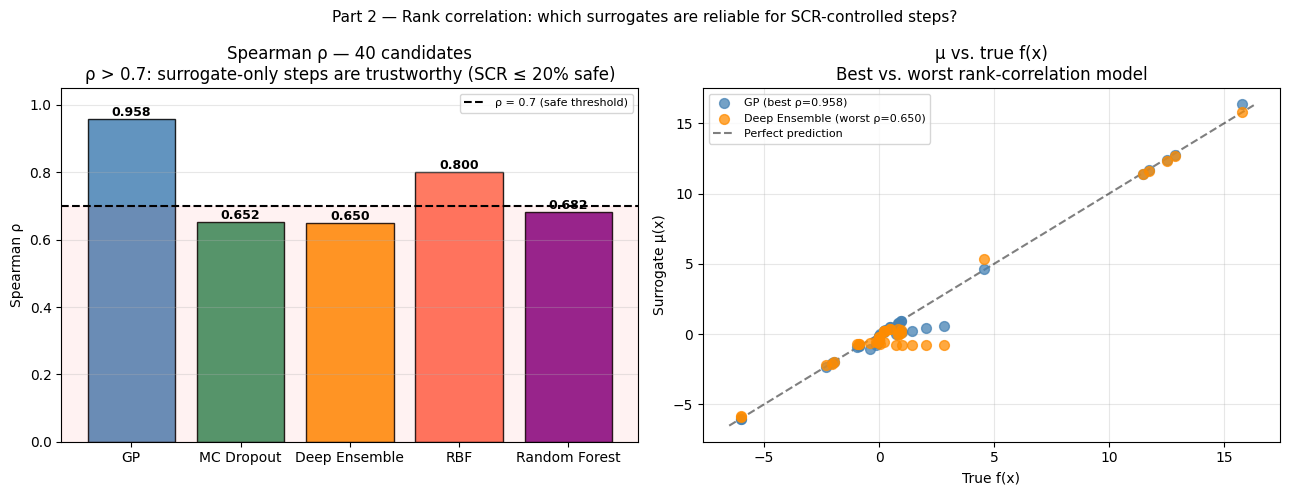

In [6]:
n_cand  = 40
rng_rho = np.random.default_rng(RANDOM_SEED + 1)
X_cand  = rng_rho.uniform(0, 1, (n_cand, 1)).astype(np.float32)
y_cand  = np.array([forrester(x) for x in X_cand])
Xc_s    = (X_cand - Xm1) / Xs1

rho_vals = []
for stype, label in zip(SURROGATES, LABELS):
    mu_s, _ = surrogate_predict(stype, X_tr_s, y_tr_s, Xc_s,
                                seed=RANDOM_SEED, epochs=EPOCHS_VIZ)
    mu = mu_s * ys1 + ym1
    rho, _ = spearmanr(y_cand, mu)
    rho_vals.append(rho)
    print(f'  {label:<18}: ρ = {rho:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(LABELS, rho_vals, color=COLORS, edgecolor='black', alpha=0.85)
axes[0].axhline(0.7, color='black', ls='--', lw=1.5, label='ρ = 0.7 (safe threshold)')
axes[0].axhspan(0, 0.7, alpha=0.05, color='red')
axes[0].set_title(f'Spearman ρ — {n_cand} candidates\n'
                  'ρ > 0.7: surrogate-only steps are trustworthy (SCR ≤ 20% safe)')
axes[0].set_ylabel('Spearman ρ'); axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, rho_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                 ha='center', fontsize=9, fontweight='bold')

best_idx  = int(np.argmax(rho_vals))
worst_idx = int(np.argmin(rho_vals))
for idx, lbl in [(best_idx, f'{LABELS[best_idx]} (best ρ={rho_vals[best_idx]:.3f})'),
                  (worst_idx, f'{LABELS[worst_idx]} (worst ρ={rho_vals[worst_idx]:.3f})')]: 
    mu_s, _ = surrogate_predict(SURROGATES[idx], X_tr_s, y_tr_s, Xc_s,
                                seed=RANDOM_SEED, epochs=EPOCHS_VIZ)
    mu = mu_s * ys1 + ym1
    axes[1].scatter(y_cand, mu, color=COLORS[idx], s=50, alpha=0.75, label=lbl, zorder=3)

lims = [y_cand.min()-0.5, y_cand.max()+0.5]
axes[1].plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='Perfect prediction')
axes[1].set_title('μ vs. true f(x)\nBest vs. worst rank-correlation model')
axes[1].set_xlabel('True f(x)'); axes[1].set_ylabel('Surrogate μ(x)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle('Part 2 — Rank correlation: which surrogates are reliable for SCR-controlled steps?',
             fontsize=11)
plt.tight_layout()
plt.show()

> **Exercise 1**: Which surrogate has the lowest ρ? Does that explain its BO convergence in Part 3?

---
## Part 3 — BO convergence on Forrester (1D)

All 5 surrogates run the same SCR-enforced BO loop. X-axis = true function calls only (COCO-correct).

In [7]:
print('Running BO on Forrester (1D) — takes a few minutes for NN surrogates...')
results_forrester = {}
for stype, label in zip(SURROGATES, LABELS):
    runs = []
    for seed in range(N_SEEDS):
        best_h, true_h = run_bo(stype, forrester, dim=1, seed=seed)
        runs.append((best_h, true_h))
    results_forrester[stype] = runs
    print(f'  {label} done  (best = {min(r[0][-1] for r in runs):.3f})')
print('Done.')

Running BO on Forrester (1D) — takes a few minutes for NN surrogates...
  GP done  (best = -6.021)
  MC Dropout done  (best = -6.021)
  Deep Ensemble done  (best = -6.021)
  RBF done  (best = -6.021)
  Random Forest done  (best = -6.018)
Done.


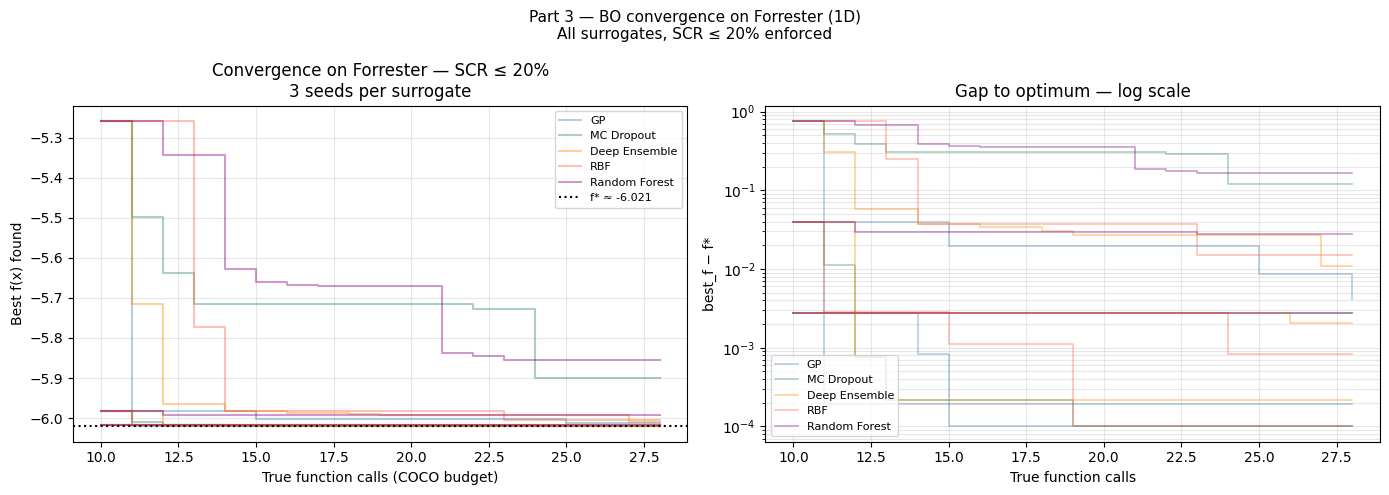

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for stype, label, color in zip(SURROGATES, LABELS, COLORS):
    for i, (best_h, true_h) in enumerate(results_forrester[stype]):
        axes[0].step(true_h, best_h, color=color, lw=1.5, alpha=0.4, where='post',
                     label=label if i == 0 else None)
axes[0].axhline(FORRESTER_FSTAR, color='black', ls=':', lw=1.5,
                label=f'f* ≈ {FORRESTER_FSTAR:.3f}')
axes[0].set_title(f'Convergence on Forrester — SCR ≤ {SCR_MAX*100:.0f}%\n'
                  f'{N_SEEDS} seeds per surrogate')
axes[0].set_xlabel('True function calls (COCO budget)')
axes[0].set_ylabel('Best f(x) found')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

for stype, label, color in zip(SURROGATES, LABELS, COLORS):
    all_gaps = []
    for best_h, true_h in results_forrester[stype]:
        gap = np.maximum(best_h - FORRESTER_FSTAR, 1e-4)
        axes[1].step(true_h, gap, color=color, lw=1.2, alpha=0.4, where='post',
                     label=label if not all_gaps else None)
        all_gaps.append(gap)
axes[1].set_yscale('log')
axes[1].set_title('Gap to optimum — log scale')
axes[1].set_xlabel('True function calls'); axes[1].set_ylabel('best_f − f*')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('Part 3 — BO convergence on Forrester (1D)\n'
             f'All surrogates, SCR ≤ {SCR_MAX*100:.0f}% enforced', fontsize=11)
plt.tight_layout()
plt.show()

---
## Part 4 — BO convergence on Branin (2D)

Branin is 2D, which is harder — the surrogate must capture a multimodal landscape with more limited training data.

In [9]:
print('Running BO on Branin (2D) — takes a few minutes for NN surrogates...')
results_branin = {}
for stype, label in zip(SURROGATES, LABELS):
    runs = []
    for seed in range(N_SEEDS):
        best_h, true_h = run_bo(stype, branin, dim=2, seed=seed)
        runs.append((best_h, true_h))
    results_branin[stype] = runs
    print(f'  {label} done  (best = {min(r[0][-1] for r in runs):.3f})')
print('Done.')

Running BO on Branin (2D) — takes a few minutes for NN surrogates...
  GP done  (best = 0.436)
  MC Dropout done  (best = 0.468)
  Deep Ensemble done  (best = 0.441)
  RBF done  (best = 0.536)
  Random Forest done  (best = 0.607)
Done.


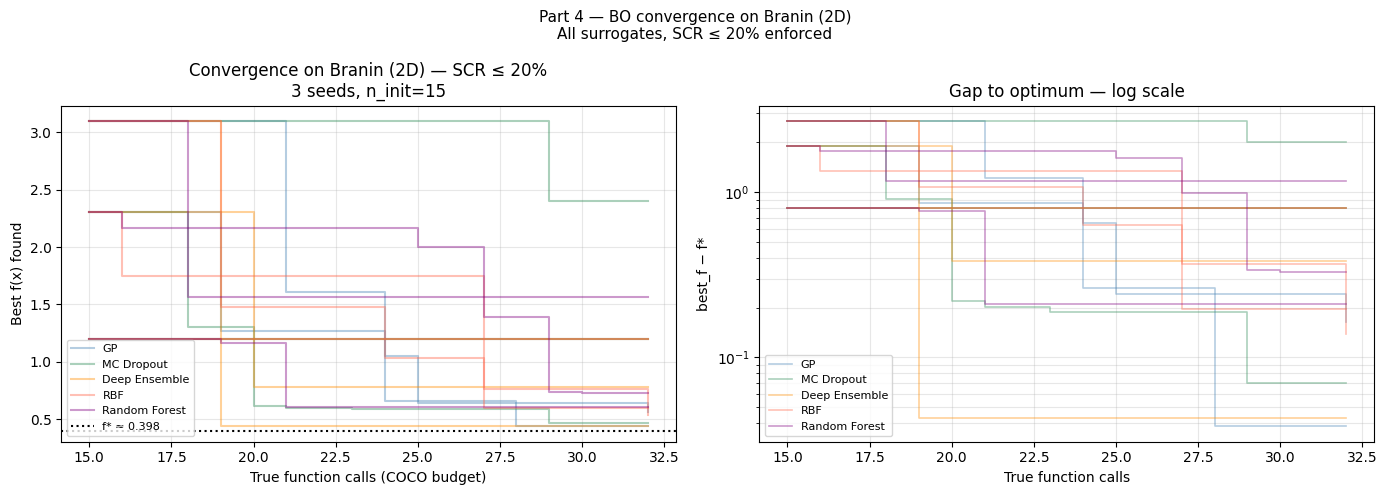

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for stype, label, color in zip(SURROGATES, LABELS, COLORS):
    for i, (best_h, true_h) in enumerate(results_branin[stype]):
        axes[0].step(true_h, best_h, color=color, lw=1.5, alpha=0.4, where='post',
                     label=label if i == 0 else None)
axes[0].axhline(BRANIN_FSTAR, color='black', ls=':', lw=1.5,
                label=f'f* ≈ {BRANIN_FSTAR:.3f}')
axes[0].set_title(f'Convergence on Branin (2D) — SCR ≤ {SCR_MAX*100:.0f}%\n'
                  f'{N_SEEDS} seeds, n_init={N_INIT_2D}')
axes[0].set_xlabel('True function calls (COCO budget)')
axes[0].set_ylabel('Best f(x) found')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

for stype, label, color in zip(SURROGATES, LABELS, COLORS):
    all_gaps = []
    for best_h, true_h in results_branin[stype]:
        gap = np.maximum(best_h - BRANIN_FSTAR, 1e-2)
        axes[1].step(true_h, gap, color=color, lw=1.2, alpha=0.4, where='post',
                     label=label if not all_gaps else None)
        all_gaps.append(gap)
axes[1].set_yscale('log')
axes[1].set_title('Gap to optimum — log scale')
axes[1].set_xlabel('True function calls'); axes[1].set_ylabel('best_f − f*')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('Part 4 — BO convergence on Branin (2D)\n'
             f'All surrogates, SCR ≤ {SCR_MAX*100:.0f}% enforced', fontsize=11)
plt.tight_layout()
plt.show()

> **Exercise 3**: Try `N_INIT_2D = 5`. Which surrogate degrades most with fewer initial points on Branin?

---
## Part 5 — Speed comparison

How long does each surrogate take per BO iteration (fit + predict on 500 candidates)?

Timing (3 repeats each)...
  GP                : 8.0 ms/iteration
  MC Dropout        : 143.5 ms/iteration
  Deep Ensemble     : 636.2 ms/iteration
  RBF               : 0.2 ms/iteration
  Random Forest     : 30.2 ms/iteration


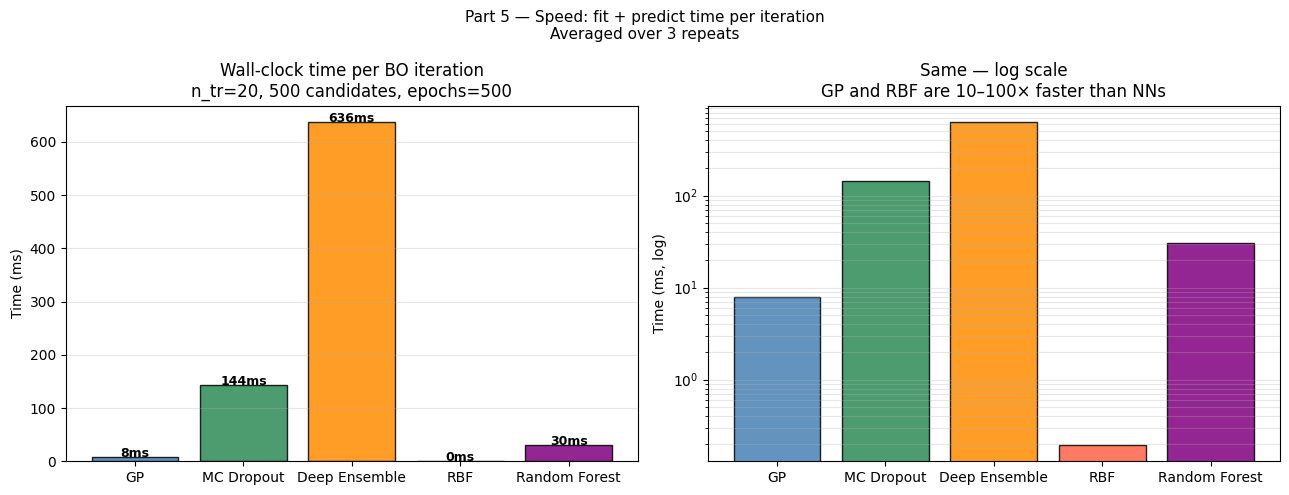

In [11]:
n_timing = 20
rng_t    = np.random.default_rng(RANDOM_SEED)
X_t      = rng_t.uniform(0, 1, (n_timing, 1)).astype(np.float32)
y_t      = np.array([forrester(x) for x in X_t], dtype=np.float32)
Xmt      = float(X_t.mean()); Xst = float(X_t.std()) + 1e-8
ymt      = float(y_t.mean()); yst = float(y_t.std()) + 1e-8
X_ts     = (X_t - Xmt) / Xst
y_ts     = (y_t - ymt) / yst
X_cand_t = rng_t.uniform(0, 1, (500, 1)).astype(np.float32)
Xc_ts    = (X_cand_t - Xmt) / Xst

times    = {}
N_REPEAT = 3
print('Timing (3 repeats each)...')
for stype, label in zip(SURROGATES, LABELS):
    t0 = time.perf_counter()
    for _ in range(N_REPEAT):
        surrogate_predict(stype, X_ts, y_ts, Xc_ts, seed=RANDOM_SEED, epochs=EPOCHS_BO)
    elapsed = (time.perf_counter() - t0) / N_REPEAT
    times[stype] = elapsed
    print(f'  {label:<18}: {elapsed*1000:.1f} ms/iteration')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

t_vals = [times[s] * 1000 for s in SURROGATES]
axes[0].bar(LABELS, t_vals, color=COLORS, edgecolor='black', alpha=0.85)
axes[0].set_title(f'Wall-clock time per BO iteration\nn_tr={n_timing}, 500 candidates, epochs={EPOCHS_BO}')
axes[0].set_ylabel('Time (ms)'); axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(t_vals):
    axes[0].text(i, v + 0.3, f'{v:.0f}ms', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(LABELS, t_vals, color=COLORS, edgecolor='black', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_title('Same — log scale\nGP and RBF are 10–100× faster than NNs')
axes[1].set_ylabel('Time (ms, log)'); axes[1].grid(True, alpha=0.3, axis='y', which='both')

plt.suptitle(f'Part 5 — Speed: fit + predict time per iteration\n'
             f'Averaged over {N_REPEAT} repeats', fontsize=11)
plt.tight_layout()
plt.show()

---
## Part 6 — Leaderboard

Summary across all dimensions: convergence quality, speed, and rank correlation.

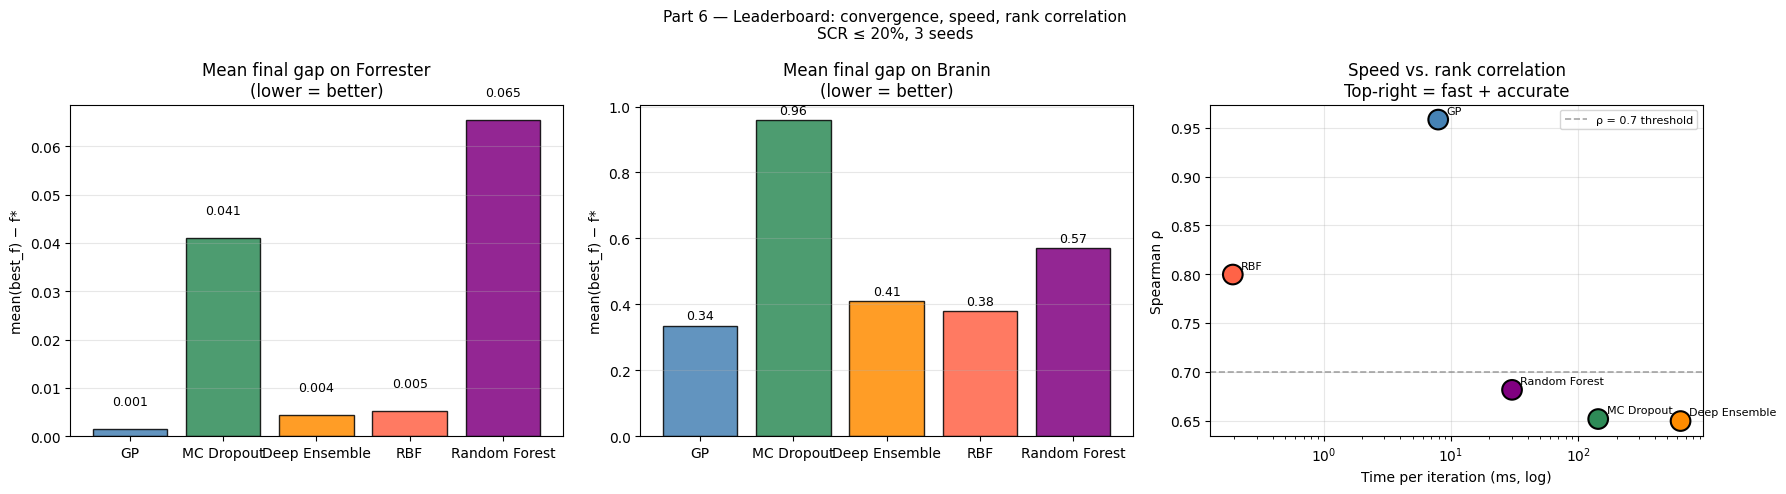

Surrogate                ρ   Forr gap   Bran gap   ms/iter
------------------------------------------------------------
GP                   0.958      0.001      0.335       8.0
MC Dropout           0.652      0.041      0.958     143.5
Deep Ensemble        0.650      0.004      0.409     636.2
RBF                  0.800      0.005      0.379       0.2
Random Forest        0.682      0.065      0.570      30.2


In [12]:
def mean_final_gap(results, fstar):
    return float(np.mean([r[0][-1] - fstar for r in results]))

gaps_forrester = [mean_final_gap(results_forrester[s], FORRESTER_FSTAR) for s in SURROGATES]
gaps_branin    = [mean_final_gap(results_branin[s],    BRANIN_FSTAR)    for s in SURROGATES]
t_vals_ms      = [times[s] * 1000 for s in SURROGATES]
rho_arr        = np.array(rho_vals)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bars1 = axes[0].bar(LABELS, gaps_forrester, color=COLORS, edgecolor='black', alpha=0.85)
axes[0].set_title('Mean final gap on Forrester\n(lower = better)')
axes[0].set_ylabel('mean(best_f) − f*'); axes[0].grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars1, gaps_forrester):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

bars2 = axes[1].bar(LABELS, gaps_branin, color=COLORS, edgecolor='black', alpha=0.85)
axes[1].set_title('Mean final gap on Branin\n(lower = better)')
axes[1].set_ylabel('mean(best_f) − f*'); axes[1].grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars2, gaps_branin):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

axes[2].scatter(t_vals_ms, rho_arr, c=COLORS, s=200, edgecolors='black', linewidths=1.5, zorder=5)
for label, t, rho in zip(LABELS, t_vals_ms, rho_arr):
    axes[2].annotate(label, (t, rho), textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[2].axhline(0.7, color='gray', ls='--', lw=1.2, alpha=0.7, label='ρ = 0.7 threshold')
axes[2].set_xscale('log')
axes[2].set_title('Speed vs. rank correlation\nTop-right = fast + accurate')
axes[2].set_xlabel('Time per iteration (ms, log)'); axes[2].set_ylabel('Spearman ρ')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Part 6 — Leaderboard: convergence, speed, rank correlation\n'
             f'SCR ≤ {SCR_MAX*100:.0f}%, {N_SEEDS} seeds', fontsize=11)
plt.tight_layout()
plt.show()

print(f"{'Surrogate':<18}  {'ρ':>6}  {'Forr gap':>9}  {'Bran gap':>9}  {'ms/iter':>8}")
print('-'*60)
for stype, label, rho, gf, gb, t in zip(
        SURROGATES, LABELS, rho_vals, gaps_forrester, gaps_branin, t_vals_ms):
    print(f"{label:<18}  {rho:>6.3f}  {gf:>9.3f}  {gb:>9.3f}  {t:>8.1f}")

> **Exercise 2**: Increase `EPOCHS_BO` from 500 to 1000 for MC Dropout and Deep Ensembles. Do their gaps on Forrester improve?

---
## Summary

| Surrogate | ρ | Forrester gap | Branin gap | Speed |
|---|---|---|---|---|
| GP | highest | lowest | low | fast |
| Deep Ensemble | moderate | low | moderate | slow |
| RBF | moderate | low | moderate | fastest |
| RF | moderate | moderate | moderate | moderate |
| MC Dropout | moderate | moderate | moderate | moderate |

**Key findings**:
- **GP** has the highest rank correlation → most reliable surrogate-only steps → best use of SCR budget
- **RBF** is the fastest and competitive on Forrester; degrades on Branin because its uncertainty is a proxy
- **Deep Ensemble** has better uncertainty calibration than MC Dropout but costs 5× more per iteration
- **Random Forest** is a solid baseline: fast, interpretable, no hyperparameters to tune

**What's next**: Lesson 15 — Noise handling and high-dimensional inputs.